# Forward vs recurrent connectivity current contribution

This notebook calculates the mean absolute current input to the model units for the feedforward compared to the recurrent connections (Supplementary Figure 2).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

In [3]:
encoding_current_df = analysis.FeedforwardVsRecurrentContribution.get_df(root, prediction_offset=0)
prediction_current_df = analysis.FeedforwardVsRecurrentContribution.get_df(root, prediction_offset=128)

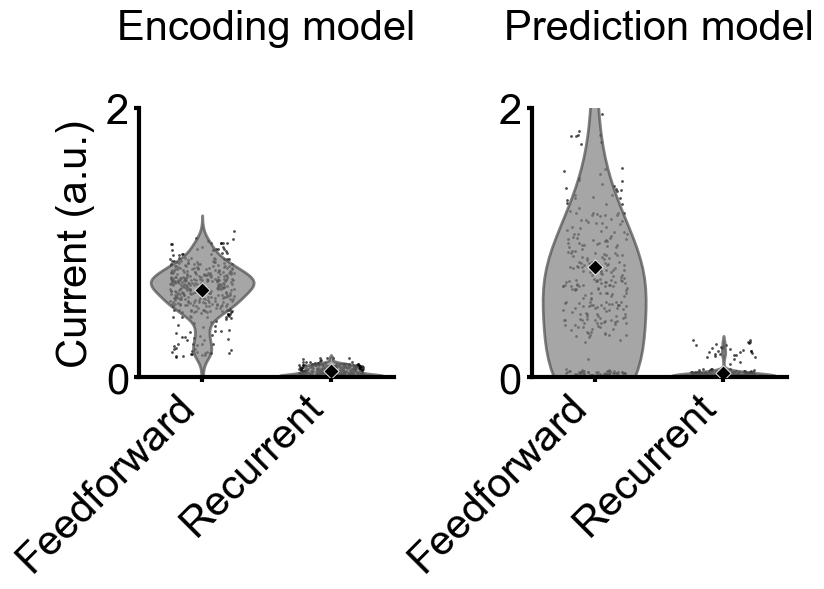

In [4]:
def plot_current_contribution(data_df, y_label, yticks, palette, ax):
    data_df = data_df.melt(var_name="type", value_name="y")

    sns.stripplot(
        data=data_df,
        x="type",
        y="y",
        ax=ax,
        color="black",
        size=2,
        jitter=0.25,
        alpha=0.25,
        zorder=1
    )
    
    sns.violinplot(
        data=data_df,
        x="type",
        y="y",
        ax=ax,
        density_norm="width",
        inner=None,
        linewidth=2,
        palette=palette,
        zorder=2
    )

    for pc in ax.collections:
        pc.set_alpha(0.7)
    
    means = data_df.groupby("type", as_index=False)["y"].mean()
    
    sns.scatterplot(
        data=means,
        x="type",
        y="y",
        ax=ax,
        color="black",
        marker="D",
        s=60,
        zorder=3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=fs, labelpad=8)
    ax.set_ylim(0, yticks[-1])
    ax.set_yticks(yticks)
    
    ax.legend().set_visible(False)

fig, axs = plt.subplots(1, 2, figsize=(8, 6))
plot_current_contribution(encoding_current_df, "Current (a.u.)", [0, 2], ["gray", "gray"], ax=axs[0])
plot_current_contribution(prediction_current_df, "Current (a.u.)", [0, 2], ["gray", "gray"], ax=axs[1])
axs[1].set_ylabel("")
axs[0].set_title("Encoding model", fontsize=30, pad=50)
axs[1].set_title("Prediction model", fontsize=30, pad=50)
fig.tight_layout()
plt.savefig(f"{root}/figures/supp/current_contribution.svg", format="svg", transparent=False, bbox_inches="tight")

In [5]:
U1, p = mannwhitneyu(encoding_current_df["Feedforward"].values, encoding_current_df["Recurrent"].values, alternative="greater")
print(p)
U1, p = mannwhitneyu(prediction_current_df["Feedforward"].values, prediction_current_df["Recurrent"].values, alternative="greater")
print(p)

1.1508269600366242e-130
3.684159531004584e-83


In [6]:
print(f"% contribution = {100*encoding_current_df['Recurrent'].mean() / (encoding_current_df['Recurrent'].mean() + encoding_current_df['Feedforward'].mean())}")

% contribution = 6.235361231779914
